#**1. RNN**

In [1]:
import torch
import torch.nn as nn
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(42)

In [2]:
batch_size = 1
seq_length = 3
embedding_dim = 3

input = torch.randint(
    high=2,
    size=(batch_size, seq_length, embedding_dim),
    dtype=torch.float32
)

input

tensor([[[0., 1., 0.],
         [0., 0., 1.],
         [0., 0., 0.]]])

In [3]:
embedding_dim = 3
hidden_size = 2
activation = 'relu'

rnn_layer = nn.RNN(
    input_size=embedding_dim,
    hidden_size=hidden_size,
    nonlinearity=activation,
    batch_first=True
)

In [4]:
rnn_layer.all_weights

[[Parameter containing:
  tensor([[-0.5188,  0.6146,  0.1323],
          [ 0.5224,  0.0958,  0.3410]], requires_grad=True),
  Parameter containing:
  tensor([[-0.0998,  0.5451],
          [ 0.1045, -0.3301]], requires_grad=True),
  Parameter containing:
  tensor([ 0.1802, -0.3258], requires_grad=True),
  Parameter containing:
  tensor([-0.0829, -0.2872], requires_grad=True)]]

In [5]:
for param in rnn_layer.parameters():
    init_kernel_weight = torch.randint(
        high=2,
        size=(param.data.shape),
        dtype=torch.float32
    )
    param.data = init_kernel_weight

In [6]:
rnn_layer.all_weights

[[Parameter containing:
  tensor([[1., 1., 1.],
          [1., 1., 1.]], requires_grad=True),
  Parameter containing:
  tensor([[1., 0.],
          [0., 1.]], requires_grad=True),
  Parameter containing:
  tensor([1., 1.], requires_grad=True),
  Parameter containing:
  tensor([0., 1.], requires_grad=True)]]

**Example 1**

In [7]:
output, hn = rnn_layer(input)

In [8]:
output

tensor([[[2., 3.],
         [4., 6.],
         [5., 8.]]], grad_fn=<TransposeBackward1>)

In [9]:
hn

tensor([[[5., 8.]]], grad_fn=<StackBackward0>)

**Example 2**

In [10]:
h0 = torch.randint(
    high=2,
    size=(1, batch_size, hidden_size),
    dtype=torch.float32
)

In [11]:
h0

tensor([[[0., 0.]]])

In [12]:
output, hn = rnn_layer(input, h0)

In [13]:
output

tensor([[[2., 3.],
         [4., 6.],
         [5., 8.]]], grad_fn=<TransposeBackward1>)

In [14]:
hn

tensor([[[5., 8.]]], grad_fn=<StackBackward0>)

#**2. Text Classification Preprocessing**

###**2.1. Load Dataset**

In [15]:
!git clone https://github.com/congnghia0609/ntc-scv.git

Cloning into 'ntc-scv'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 39 (delta 0), reused 4 (delta 0), pack-reused 35 (from 1)
Receiving objects: 100% (39/39), 186.94 MiB | 19.21 MiB/s, done.
Resolving deltas: 100% (9/9), done.
Updating files: 100% (11/11), done.


In [16]:
!unzip ./ntc-scv/data/data_test.zip -d ./data
!unzip ./ntc-scv/data/data_train.zip -d ./data
!rm -rf ./ntc-scv

Streaming output truncated to the last 5000 lines.
  inflating: ./data/data_train/train/pos/31228.txt  
  inflating: ./data/data_train/train/pos/3123.txt  
  inflating: ./data/data_train/train/pos/31232.txt  
  inflating: ./data/data_train/train/pos/31233.txt  
  inflating: ./data/data_train/train/pos/31234.txt  
  inflating: ./data/data_train/train/pos/31236.txt  
  inflating: ./data/data_train/train/pos/31238.txt  
  inflating: ./data/data_train/train/pos/31240.txt  
  inflating: ./data/data_train/train/pos/31242.txt  
  inflating: ./data/data_train/train/pos/31247.txt  
  inflating: ./data/data_train/train/pos/31250.txt  
  inflating: ./data/data_train/train/pos/31251.txt  
  inflating: ./data/data_train/train/pos/31252.txt  
  inflating: ./data/data_train/train/pos/31257.txt  
  inflating: ./data/data_train/train/pos/31260.txt  
  inflating: ./data/data_train/train/pos/31261.txt  
  inflating: ./data/data_train/train/pos/31262.txt  
  inflating: ./data/data_train/train/pos/31273.tx

In [17]:
import os
import pandas as pd

def load_data_from_path(folder_path):
    examples = []
    for label in os.listdir(folder_path):
        full_path = os.path.join(folder_path, label)
        for file_name in os.listdir(full_path):
            file_path = os.path.join(full_path, file_name)
            with open(file_path, "r", encoding="utf-8") as f:
                lines = f.readlines()
            sentence = " ".join(lines)
            if label == "neg":
                label = 0
            if label == "pos":
                label = 1
            data = {
                'sentence': sentence,
                'label': label
            }
            examples.append(data)
    return pd.DataFrame(examples)

In [18]:
folder_paths = {
    'train': 'data/data_train/train',
    'valid': 'data/data_train/test',
    'test': 'data/data_test/test'
}

train_df = load_data_from_path(folder_paths['train'])
valid_df = load_data_from_path(folder_paths['valid'])
test_df = load_data_from_path(folder_paths['test'])

###**2.2. Preprocessing**

**Language Detection**

In [19]:
!pip install langid

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 30.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langid: filename=langid-1.1.6-py3-none-any.whl size=1941171 sha256=f88051ddc913bab2834c73d0091353923c1ce60b98dae72dd646c0cace589e9a
  Stored in directory: /root/.cache/pip/wheels/23/c8/c6/eed80894918490a175677414d40bd7c851413bbe03d4856c3c
Successfully built langid


In [20]:
from langid.langid import LanguageIdentifier, model

def identify_vn(df):
    identifier = LanguageIdentifier.from_modelstring(model, norm_probs=True)
    not_vi_idx = set()
    THRESHOLD = 0.9
    for idx, row in df.iterrows():
        score = identifier.classify(row["sentence"])
        if score[0] != "vi" or (score[0] == "vi" and score[1] <= THRESHOLD):
            not_vi_idx.add(idx)
    vi_df = df[~df.index.isin(not_vi_idx)]
    not_vi_df = df[df.index.isin(not_vi_idx)]
    return vi_df, not_vi_df

In [21]:
train_df_vi, train_df_other = identify_vn(train_df)

**Text Cleaning**

In [22]:
import re
import string

def preprocess_text(text):
    # remove URLs https://www.
    url_pattern = re.compile(r'https?://\s+\wwww\.\s+')
    text = url_pattern.sub(r" ", text)

    # remove HTML Tags: <>
    html_pattern = re.compile(r'<[^<>]+>')
    text = html_pattern.sub(" ", text)

    # remove puncs and digits
    replace_chars = list(string.punctuation + string.digits)
    for char in replace_chars:
        text = text.replace(char, " ")

    # remove emoji
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U0001F1F2-\U0001F1F4"  # Macau flag
        u"\U0001F1E6-\U0001F1FF"  # flags
        u"\U0001F600-\U0001F64F"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        u"\U0001f926-\U0001f937"
        u"\U0001F1F2"
        u"\U0001F1F4"
        u"\U0001F620"
        u"\u200d"
        u"\u2640-\u2642"
        "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r" ", text)

    # normalize whitespace
    text = " ".join(text.split())

    # lowercasing
    text = text.lower()
    return text

In [23]:
train_df_vi['preprocess_sentence'] = [preprocess_text(row['sentence']) for index, row in train_df_vi.iterrows()]
valid_df['preprocess_sentence'] = [preprocess_text(row['sentence']) for index, row in valid_df.iterrows()]
test_df['preprocess_sentence'] = [preprocess_text(row['sentence']) for index, row in test_df.iterrows()]

<ipython-input-23-e21d2b59a2cb>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df_vi['preprocess_sentence'] = [preprocess_text(row['sentence']) for index, row in train_df_vi.iterrows()]


###**2.3. Representation**

In [24]:
!pip install tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.9 MB/s eta 0:00:00


In [25]:
vocab_size = 10000

In [26]:
from collections import Counter
def create_vocab(sentences, vocab_size=10000):
    # Count word frequencies
    word_counts = Counter()
    for sentence in sentences:
        for word in sentence.split():
            word_counts[word] += 1

    # Select most common words
    most_common_words = word_counts.most_common(vocab_size - 2)  # -2 for <pad> and <unk>
    vocab = ["<pad>", "<unk>"] + [word for word, _ in most_common_words]

    # Map words to indices
    word_to_id = {word: idx for idx, word in enumerate(vocab)}
    return vocab, word_to_id

train_sentences = train_df_vi['preprocess_sentence'].tolist()
vocab, word_to_id = create_vocab(train_sentences, vocab_size=vocab_size)

print("Vocabulary size:", len(vocab))
print("Sample vocabulary:", vocab[:10])  # Print the first 10 words


Vocabulary size: 10000
Sample vocabulary: ['<pad>', '<unk>', 'ăn', 'mình', 'có', 'là', 'không', 'quán', 'thì', 'và']


In [27]:
def encode_sentence(sentence, word_to_id, unk_token="<unk>"):
    unk_id = word_to_id[unk_token]
    return [word_to_id.get(word, unk_id) for word in sentence.split()]

###**2.4. Dataloader**

In [28]:
from torch.utils.data import Dataset, DataLoader
class CustomDataset(Dataset):
    def __init__(self, df, word_to_id, seq_length):
        self.sentences = df['preprocess_sentence'].tolist()
        self.labels = df['label'].tolist()
        self.word_to_id = word_to_id
        self.seq_length = seq_length

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        # Tokenize and encode the sentence
        sentence = self.sentences[idx]
        label = self.labels[idx]
        encoded_sentence = encode_sentence(sentence, self.word_to_id)

        # Apply padding or truncation
        if len(encoded_sentence) < self.seq_length:
            encoded_sentence += [0] * (self.seq_length - len(encoded_sentence))
        else:
            encoded_sentence = encoded_sentence[:self.seq_length]

        return torch.tensor(encoded_sentence, dtype=torch.long), torch.tensor(label, dtype=torch.long)

seq_length = 50
train_dataset = CustomDataset(train_df_vi, word_to_id, seq_length)
valid_dataset = CustomDataset(valid_df, word_to_id, seq_length)
test_dataset = CustomDataset(test_df, word_to_id, seq_length)

In [29]:
batch_size = 128

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [30]:
import numpy
print(numpy.__version__)  # Kiểm tra phiên bản

1.26.4


In [31]:
import torch
import numpy as np

print("PyTorch version:", torch.__version__)
print("Numpy version:", np.__version__)


PyTorch version: 2.5.1+cu121
Numpy version: 1.26.4


In [32]:
next(iter(train_dataloader))

[tensor([[  74,  130,  186,  ...,  214,    6,  117],
         [   4,  539,   14,  ...,    0,    0,    0],
         [   2,   19,   20,  ...,   61,   10,  110],
         ...,
         [   7,  190,  102,  ...,   27,   25,  145],
         [  63,   23,  377,  ...,    0,    0,    0],
         [ 119,    3,   55,  ...,    8, 1651,  137]]),
 tensor([1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1,
         0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1,
         0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
         1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1,
         0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
         1, 0, 1, 0, 0, 1, 1, 0])]

In [33]:
len(train_dataloader)

233

In [34]:
encoded_sentences, labels = next(iter(train_dataloader))

In [35]:
encoded_sentences.shape

torch.Size([128, 50])

In [36]:
labels.shape

torch.Size([128])

###**2.5. Trainer**

In [37]:
import time

def train_epoch(model, optimizer, criterion, train_dataloader, device, epoch=0, log_interval=50):
    model.train()
    total_acc, total_count = 0, 0
    losses = []
    start_time = time.time()

    for idx, (inputs, labels) in enumerate(train_dataloader):
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        predictions = model(inputs, device)

        # compute loss
        loss = criterion(predictions, labels)
        losses.append(loss.item())

        # backward
        loss.backward()
        optimizer.step()
        total_acc += (predictions.argmax(1) == labels).sum().item()
        total_count += labels.size(0)
        if idx % log_interval == 0 and idx > 0:
            elapsed = time.time() - start_time
            print(
                "| epoch {:3d} | {:5d}/{:5d} batches "
                "| accuracy {:8.3f}".format(
                    epoch, idx, len(train_dataloader), total_acc / total_count
                )
            )
            total_acc, total_count = 0, 0
            start_time = time.time()

    epoch_acc = total_acc / total_count
    epoch_loss = sum(losses) / len(losses)
    return epoch_acc, epoch_loss

In [38]:
def evaluate_epoch(model, criterion, valid_dataloader, device):
    model.eval()
    total_acc, total_count = 0, 0
    losses = []

    with torch.no_grad():
        for idx, (inputs, labels) in enumerate(valid_dataloader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            predictions = model(inputs, device)

            loss = criterion(predictions, labels)
            losses.append(loss.item())

            total_acc += (predictions.argmax(1) == labels).sum().item()
            total_count += labels.size(0)

    epoch_acc = total_acc / total_count
    epoch_loss = sum(losses) / len(losses)
    return epoch_acc, epoch_loss

In [39]:
def train(model, model_name, save_model, optimizer, criterion, train_dataloader, valid_dataloader, num_epochs, device):
    train_accs, train_losses = [], []
    eval_accs, eval_losses = [], []
    best_loss_eval = 100
    times = []
    for epoch in range(1, num_epochs+1):
        epoch_start_time = time.time()
        # Training
        train_acc, train_loss = train_epoch(model, optimizer, criterion, train_dataloader, device, epoch)
        train_accs.append(train_acc)
        train_losses.append(train_loss)

        # Evaluation
        eval_acc, eval_loss = evaluate_epoch(model, criterion, valid_dataloader, device)
        eval_accs.append(eval_acc)
        eval_losses.append(eval_loss)

        # Save best model
        if eval_loss < best_loss_eval:
            torch.save(model.state_dict(), save_model + f'/{model_name}.pt')

        times.append(time.time() - epoch_start_time)
        # Print loss, acc end epoch
        print("-" * 59)
        print(
            "| End of epoch {:3d} | Time: {:5.2f}s | Train Accuracy {:8.3f} | Train Loss {:8.3f} "
            "| Valid Accuracy {:8.3f} | Valid Loss {:8.3f} ".format(
                epoch, time.time() - epoch_start_time, train_acc, train_loss, eval_acc, eval_loss
            )
        )
        print("-" * 59)

    # Load best model
    model.load_state_dict(torch.load(save_model + f'/{model_name}.pt'))
    model.eval()
    metrics = {
        'train_accuracy': train_accs,
        'train_loss': train_losses,
        'valid_accuracy': eval_accs,
        'valid_loss': eval_losses,
        'time': times
    }
    return model, metrics

In [40]:
import matplotlib.pyplot as plt

def plot_result(num_epochs, train_accs, eval_accs, train_losses, eval_losses):
    epochs = list(range(num_epochs))
    fig, axs = plt.subplots(nrows = 1, ncols =2 , figsize = (12,6))
    axs[0].plot(epochs, train_accs, label = "Training")
    axs[0].plot(epochs, eval_accs, label = "Evaluation")
    axs[1].plot(epochs, train_losses, label = "Training")
    axs[1].plot(epochs, eval_losses, label = "Evaluation")
    axs[0].set_xlabel("Epochs")
    axs[1].set_xlabel("Epochs")
    axs[0].set_ylabel("Accuracy")
    axs[1].set_ylabel("Loss")
    plt.legend()

#**3. RNN**

###**3.1. Modeling**

In [41]:
from torch import nn
from torch.nn import functional as F

embedding_dim = 200
hidden_size = 50

class RNNClassifier(nn.Module):
    def __init__(self, num_classes):
        super(RNNClassifier, self).__init__()
        self.embedding_layer = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim
        )
        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            batch_first=True
        )
        self.linear = nn.Linear(hidden_size, num_classes)

    def forward(self, X_batch, device):
        embeddings = self.embedding_layer(X_batch)
        output, hidden = self.rnn(
            embeddings,
            torch.randn(1, len(X_batch), hidden_size).to(device)
        )
        output = self.linear(output[: , -1])
        return output

In [42]:
model = RNNClassifier(num_classes=2)

In [44]:
predictions = model(encoded_sentences, device='cpu')

In [45]:
predictions.shape

torch.Size([128, 2])

###**3.2. Training**

In [46]:
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = RNNClassifier(num_classes=2)
model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

num_epochs = 100
save_model = './model'
os.makedirs(save_model, exist_ok = True)
model_name = 'model'

model, metrics = train(
    model, model_name, save_model, optimizer, criterion, train_dataloader, valid_dataloader, num_epochs, device
)

| epoch   1 |    50/  233 batches | accuracy    0.492
| epoch   1 |   100/  233 batches | accuracy    0.509
| epoch   1 |   150/  233 batches | accuracy    0.500
| epoch   1 |   200/  233 batches | accuracy    0.500
-----------------------------------------------------------
| End of epoch   1 | Time:  3.78s | Train Accuracy    0.511 | Train Loss    0.715 | Valid Accuracy    0.511 | Valid Loss    0.707 
-----------------------------------------------------------
| epoch   2 |    50/  233 batches | accuracy    0.508
| epoch   2 |   100/  233 batches | accuracy    0.513
| epoch   2 |   150/  233 batches | accuracy    0.516
| epoch   2 |   200/  233 batches | accuracy    0.539
-----------------------------------------------------------
| End of epoch   2 | Time:  2.32s | Train Accuracy    0.524 | Train Loss    0.697 | Valid Accuracy    0.515 | Valid Loss    0.698 
-----------------------------------------------------------
| epoch   3 |    50/  233 batches | accuracy    0.539
| epoch   3 

<ipython-input-39-1fa56578695b>:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_model + f'/{model_name}.pt'))


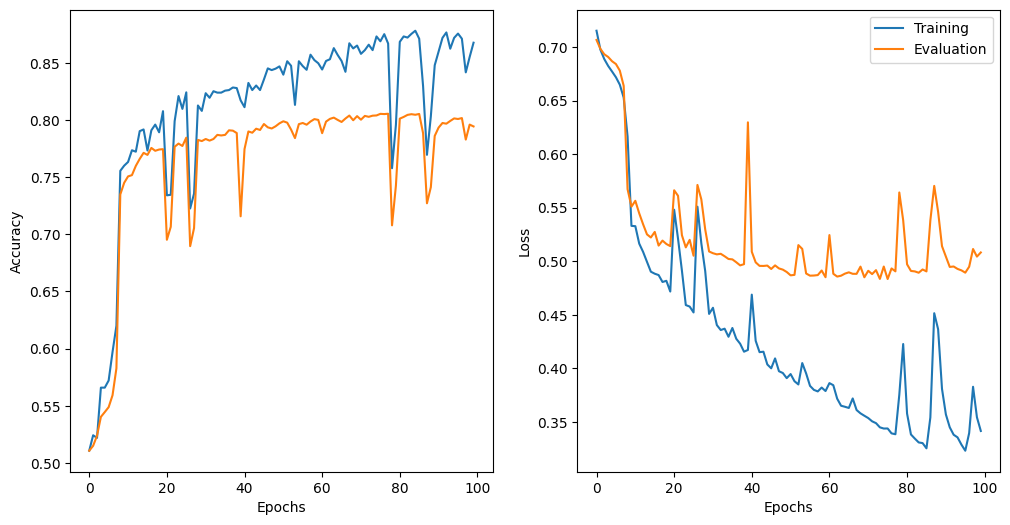

In [47]:
plot_result(
    num_epochs,
    metrics["train_accuracy"],
    metrics["valid_accuracy"],
    metrics["train_loss"],
    metrics["valid_loss"]
)

In [48]:
test_acc, test_loss = evaluate_epoch(model, criterion, test_dataloader, device)
test_acc, test_loss

(0.8009, 0.4935434690759152)

#**4. LSTM**

###**4.1. Modeling**

In [49]:
from torch import nn
from torch.nn import functional as F

embedding_dim = 200
hidden_size = 50

class LSTMClassifier(nn.Module):
    def __init__(self, num_classes):
        super(LSTMClassifier, self).__init__()
        self.embedding_layer = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim
        )
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            batch_first=True
        )
        self.linear = nn.Linear(hidden_size, num_classes)

    def forward(self, X_batch, device):
        embeddings = self.embedding_layer(X_batch)
        output, (hidden, cell) = self.lstm(embeddings)
        output = self.linear(output[:, -1, :])
        return output

In [50]:
model = LSTMClassifier(num_classes=2)

In [51]:
predictions = model(encoded_sentences, device=device)

In [52]:
predictions.shape

torch.Size([128, 2])

###**4.2. Training**

In [53]:
import torch.optim as optim

model = LSTMClassifier(num_classes=2)
model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

num_epochs = 100
save_model = './model'
os.makedirs(save_model, exist_ok = True)
model_name = 'model'

model, metrics = train(
    model, model_name, save_model, optimizer, criterion, train_dataloader, valid_dataloader, num_epochs, device
)

| epoch   1 |    50/  233 batches | accuracy    0.501
| epoch   1 |   100/  233 batches | accuracy    0.498
| epoch   1 |   150/  233 batches | accuracy    0.513
| epoch   1 |   200/  233 batches | accuracy    0.524
-----------------------------------------------------------
| End of epoch   1 | Time:  2.57s | Train Accuracy    0.541 | Train Loss    0.694 | Valid Accuracy    0.531 | Valid Loss    0.691 
-----------------------------------------------------------
| epoch   2 |    50/  233 batches | accuracy    0.544
| epoch   2 |   100/  233 batches | accuracy    0.547
| epoch   2 |   150/  233 batches | accuracy    0.558
| epoch   2 |   200/  233 batches | accuracy    0.563
-----------------------------------------------------------
| End of epoch   2 | Time:  3.32s | Train Accuracy    0.568 | Train Loss    0.684 | Valid Accuracy    0.548 | Valid Loss    0.684 
-----------------------------------------------------------
| epoch   3 |    50/  233 batches | accuracy    0.587
| epoch   3 

<ipython-input-39-1fa56578695b>:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_model + f'/{model_name}.pt'))


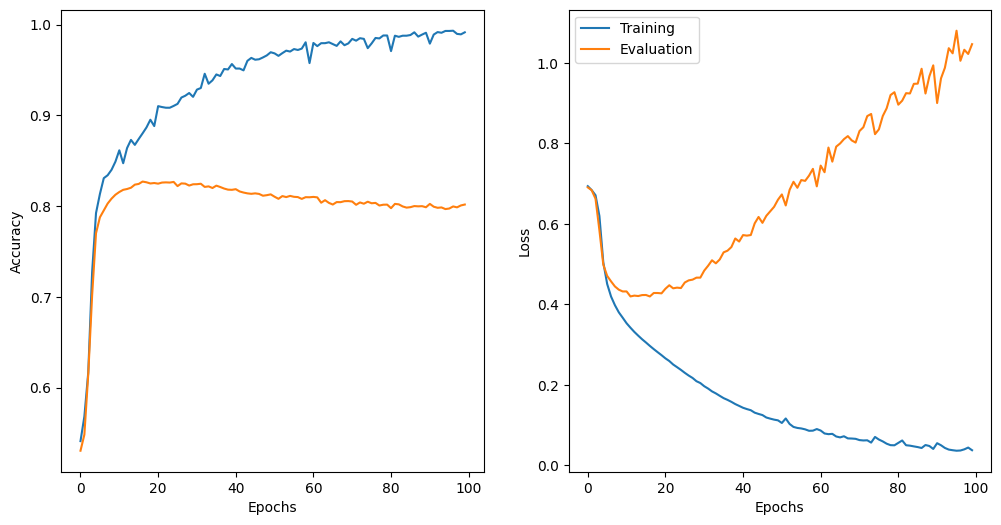

In [54]:
plot_result(
    num_epochs,
    metrics["train_accuracy"],
    metrics["valid_accuracy"],
    metrics["train_loss"],
    metrics["valid_loss"]
)

In [55]:
test_acc, test_loss = evaluate_epoch(model, criterion, test_dataloader, device)
test_acc, test_loss

(0.8087, 1.0128221779684476)